Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 506 files belonging to 3 classes.
Classes: ['brain_tumor_dataset', 'no', 'yes']
Epoch 1/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - accuracy: 0.4010 - loss: 1.2799
Epoch 2/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.4609 - loss: 0.9717
Epoch 3/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.4896 - loss: 0.9456
Epoch 4/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.4896 - loss: 0.9170
Epoch 5/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.4766 - loss: 0.9116
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 802ms/step - accuracy: 0.4672 - loss: 0.9226


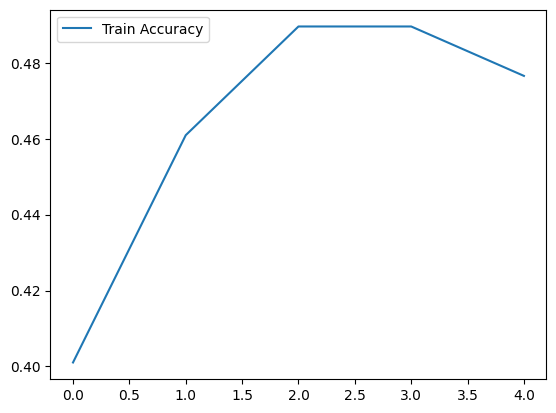

In [17]:
# ================================

# Brain Tumor Detection using CNN (Colab + Google Drive)

# ================================

# 1. Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

# 2. Set Dataset Path (CHANGE if needed)

DATASET_PATH = "/content/drive/MyDrive/Brain_Tumor_Dataset"

# 3. Import Libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras import layers, models

# 4. Load Dataset

dataset = tf.keras.preprocessing.image_dataset_from_directory(
DATASET_PATH,
image_size=(224,224),
batch_size=32
)

# 5. Check Classes (AUTO FIX)

print("Classes:", dataset.class_names)
num_classes = len(dataset.class_names)

# 6. Normalize Data

dataset = dataset.map(lambda x, y: (x/255.0, y))

# 7. Split Dataset

train_size = int(0.8 * len(dataset))
train_dataset = dataset.take(train_size)
test_dataset = dataset.skip(train_size)

# 8. Build CNN Model

model = models.Sequential([
layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
layers.MaxPooling2D((2,2)),


layers.Conv2D(64,(3,3),activation='relu'),
layers.MaxPooling2D((2,2)),

layers.Conv2D(128,(3,3),activation='relu'),
layers.MaxPooling2D((2,2)),

layers.Flatten(),
layers.Dense(128,activation='relu'),

# AUTO FIXED OUTPUT LAYER
layers.Dense(num_classes, activation='softmax')


])

# 9. Compile Model

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

# 10. Train Model

history = model.fit(train_dataset, epochs=5)

# 11. Evaluate Model

model.evaluate(test_dataset)

# 12. Plot Accuracy

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.legend()
plt.show()



